In [1]:
!git clone https://github.com/elifizg/deep-learning-cifar10-transfer-learning-and-distillation.git
%cd deep-learning-cifar10-transfer-learning-and-distillation

Cloning into 'deep-learning-cifar10-transfer-learning-and-distillation'...
remote: Enumerating objects: 228, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 228 (delta 2), reused 5 (delta 1), pack-reused 217 (from 3)
Receiving objects: 100% (228/228), 159.52 MiB | 42.29 MiB/s, done.
Resolving deltas: 100% (100/100), done.
Updating files: 100% (44/44), done.
/content/deep-learning-cifar10-transfer-learning-and-distillation


In [ ]:
# 2. Required packages
!pip install ptflops -q

In [ ]:
# 3. GPU check
import torch
print(torch.cuda.is_available())  # True olmalı

True


In [ ]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Wed Mar 18 14:25:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!git pull

remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 4 (delta 3), reused 4 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 620 bytes | 310.00 KiB/s, done.
From https://github.com/elifizg/deep-learning-cifar10-transfer-learning-and-distillation
   defa72f..a16c7cf  main       -> origin/main
Updating defa72f..a16c7cf
Fast-forward
 parameters.py | 7 +++++++
 pretrained.py | 2 +-
 2 files changed, 8 insertions(+), 1 deletion(-)


In [ ]:
# Part A — Transfer Learning:
!python main.py --mode transfer --model resnet18 --epochs 20 --transfer_option 0 --lr 1e-4 --batch_size 128 --tsne


  Dataset          : cifar10
  Model            : resnet18
  Mode             : transfer
  Device           : cuda

  Dataset split  —  train: 45,000  |  val: 5,000  |  test: 10,000

  Transfer Learning — resnet18_option1
  Trainable params : 5,130 / 11,181,642

Epoch 1/20  (lr=1.00e-04)
    [ 100/352]  loss: 2.2242  acc: 0.1856
    [ 200/352]  loss: 2.0363  acc: 0.3028
    [ 300/352]  loss: 1.8853  acc: 0.3893
  train  loss=1.8178  acc=0.4239
  val    loss=1.3733  acc=0.6422  <- checkpoint decision
  [saved]  val_acc=0.6422  ->  best_resnet18_option1.pth

Epoch 2/20  (lr=1.00e-04)
    [ 100/352]  loss: 1.3096  acc: 0.6636
    [ 200/352]  loss: 1.2532  acc: 0.6761
    [ 300/352]  loss: 1.2011  acc: 0.6894
  train  loss=1.1775  acc=0.6942
  val    loss=1.0260  acc=0.7216  <- checkpoint decision
  [saved]  val_acc=0.7216  ->  best_resnet18_option1.pth

Epoch 3/20  (lr=1.00e-04)
    [ 100/352]  loss: 1.0094  acc: 0.7275
    [ 200/352]  loss: 0.9813  acc: 0.7336
    [ 300/352]  loss: 0.95

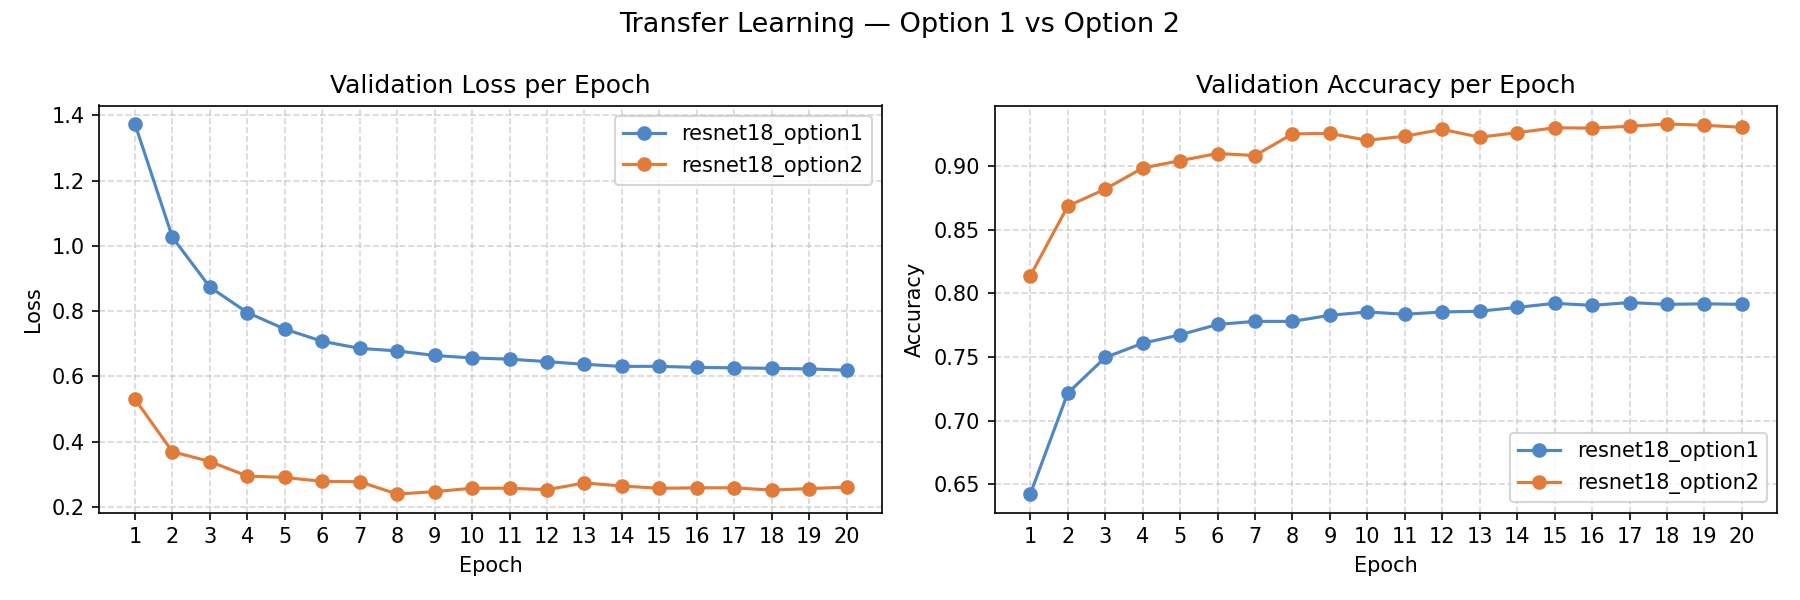

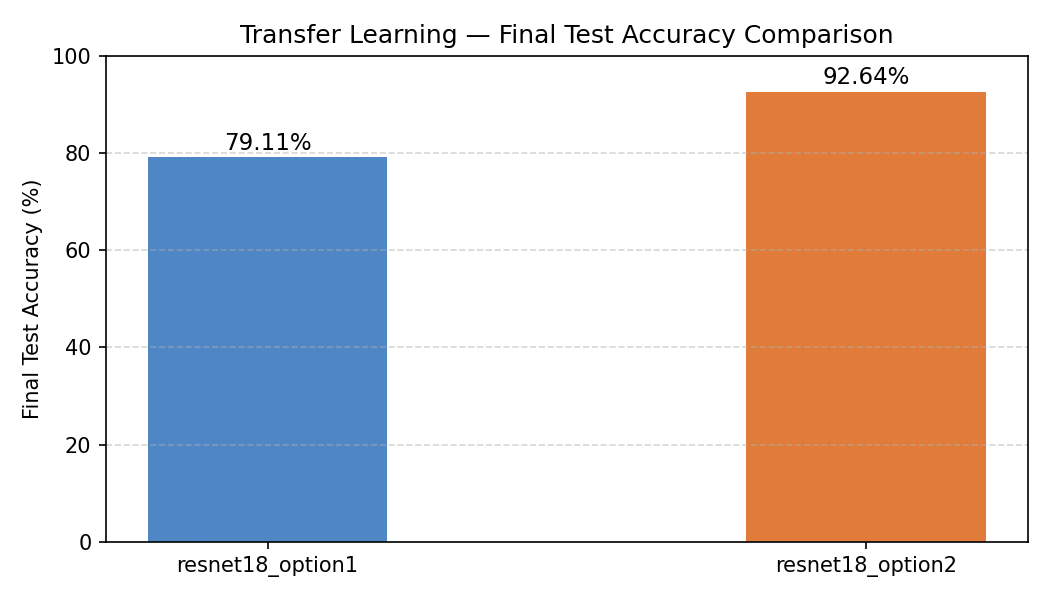

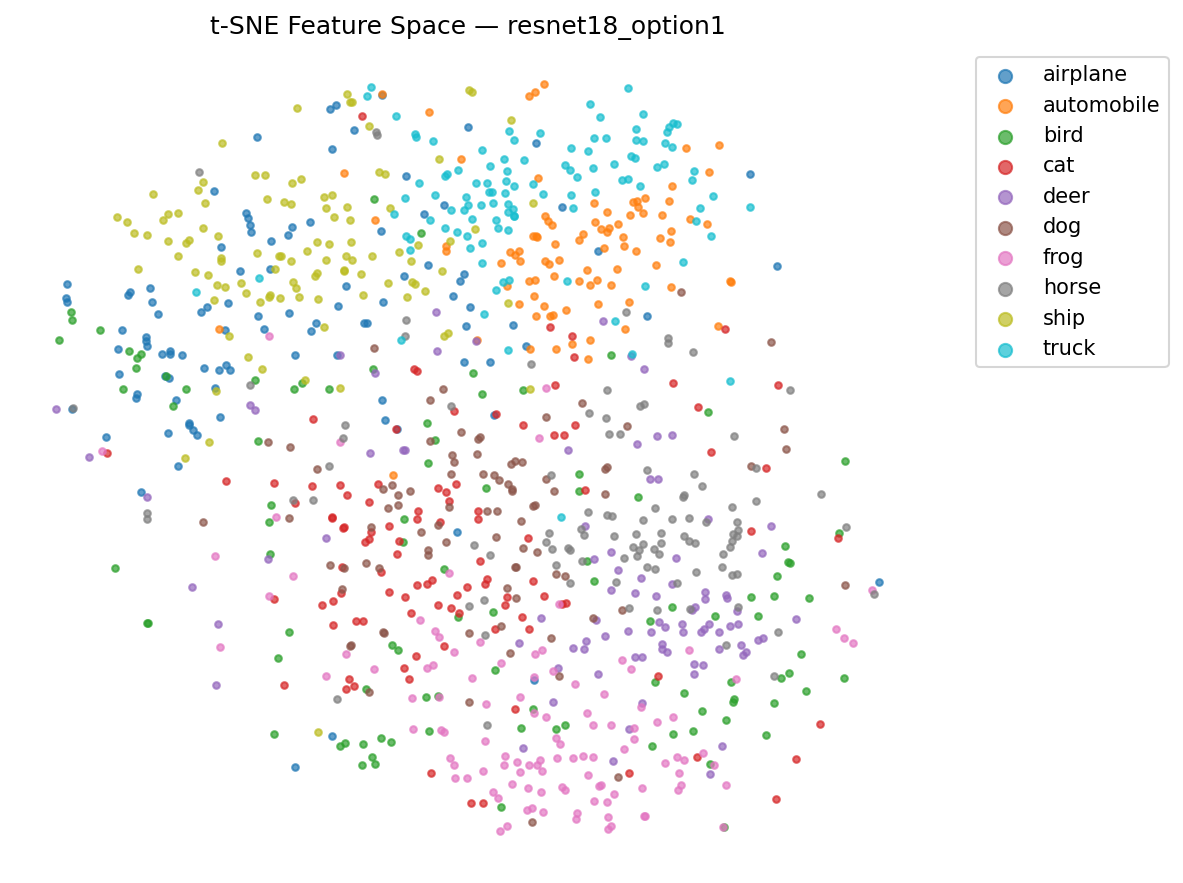

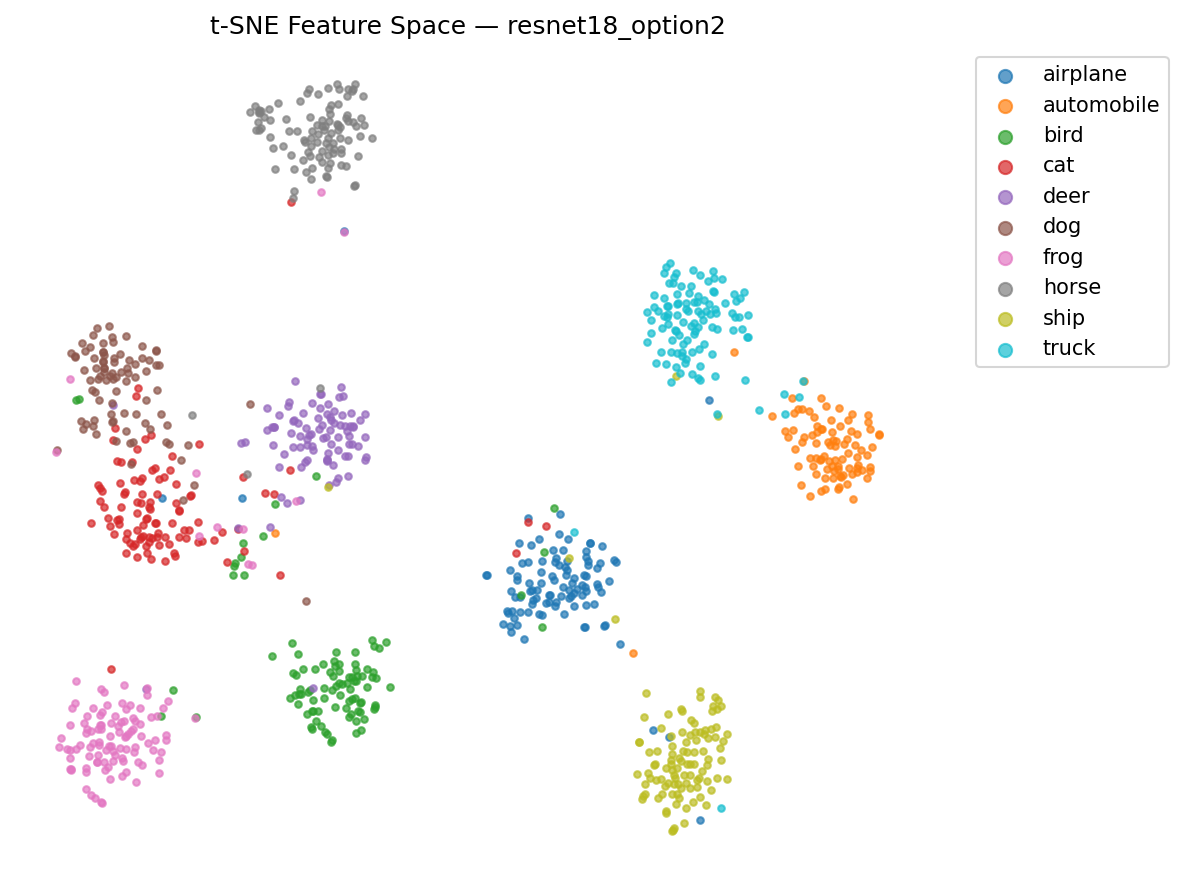

In [ ]:
from IPython.display import Image, display

display(Image('/content/deep-learning-cifar10-transfer-learning-and-distillation/resnet18_curves.png'))
display(Image('/content/deep-learning-cifar10-transfer-learning-and-distillation/resnet18_comparison.png'))
display(Image('/content/deep-learning-cifar10-transfer-learning-and-distillation/resnet18_resnet18_option1_tsne.png'))
display(Image('/content/deep-learning-cifar10-transfer-learning-and-distillation/resnet18_resnet18_option2_tsne.png'))

In [ ]:
from google.colab import files
files.download('/content/deep-learning-cifar10-transfer-learning-and-distillation/resnet18_curves.png')
files.download('/content/deep-learning-cifar10-transfer-learning-and-distillation/resnet18_comparison.png')
files.download('/content/deep-learning-cifar10-transfer-learning-and-distillation/resnet18_resnet18_option1_tsne.png')
files.download('/content/deep-learning-cifar10-transfer-learning-and-distillation/resnet18_resnet18_option2_tsne.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!python main.py --mode kd --epochs 30


  Mode : kd  |  Device : cuda


  Running experiment: B1
  Dataset : cifar10 | Model : SimpleCNN | Device : cuda
  Dataset split  —  train: 45,000  |  val: 5,000  |  test: 10,000
  Loss: CrossEntropyLoss  (standard)

Epoch 1/30  (lr=1.00e-03)
    [ 100/704]  loss: 2.4160  acc: 0.2191
    [ 200/704]  loss: 2.1080  acc: 0.2829
    [ 300/704]  loss: 1.9454  acc: 0.3239
    [ 400/704]  loss: 1.8422  acc: 0.3546
    [ 500/704]  loss: 1.7710  acc: 0.3773
    [ 600/704]  loss: 1.7170  acc: 0.3949
    [ 700/704]  loss: 1.6710  acc: 0.4091
  train  loss=1.6695  acc=0.4095
  val    loss=1.2977  acc=0.5274
  [saved]  val_acc=0.5274  ->  best_cnn_baseline.pth

Epoch 2/30  (lr=1.00e-03)
    [ 100/704]  loss: 1.3517  acc: 0.5220
    [ 200/704]  loss: 1.3393  acc: 0.5235
    [ 300/704]  loss: 1.3306  acc: 0.5244
    [ 400/704]  loss: 1.3122  acc: 0.5316
    [ 500/704]  loss: 1.2954  acc: 0.5373
    [ 600/704]  loss: 1.2871  acc: 0.5411
    [ 700/704]  loss: 1.2719  acc: 0.5478
  train  loss=1.2719  

In [11]:
import json

with open("history_MobileNet__hybrid_KD_LS_.json") as f:
    data = json.load(f)

data["label"] = "MobileNet (hybrid KD, teacher-prob)"

with open("history_MobileNet__hybrid_KD_LS_.json", "w") as f:
    json.dump(data, f, indent=2)

print("Done:", data["label"])

Done: MobileNet (hybrid KD, teacher-prob)


In [21]:
!python plot_results.py

Device: cuda
  Loaded: history_SimpleCNN__baseline_.json
  Loaded: history_ResNet__no_LS_.json
  Loaded: history_ResNet__LS_0_1_.json
  Loaded: history_SimpleCNN__KD_.json
  Loaded: history_MobileNet__hybrid_KD_LS_.json
  SimpleCNN (baseline)          acc=0.7677  flops=0.55 M params
  ResNet (no LS)                acc=0.9149  flops=11.17 M params
  ResNet (LS=0.1)               acc=0.9217  flops=11.17 M params
  SimpleCNN (KD)                acc=0.7680  flops=0.55 M params
  MobileNet (hybrid KD, teacher-prob)  acc=0.8905  flops=2.30 M params

  Experiment                    Test Acc               FLOPs
────────────────────────────────────────────────────────────────────
  SimpleCNN (baseline)           0.7677       0.55 M params
  ResNet (no LS)                 0.9149      11.17 M params
  ResNet (LS=0.1)                0.9217      11.17 M params
  SimpleCNN (KD)                 0.7680       0.55 M params
  MobileNet (hybrid KD, teacher-prob)   0.8905       2.30 M params
Saved: b_fina

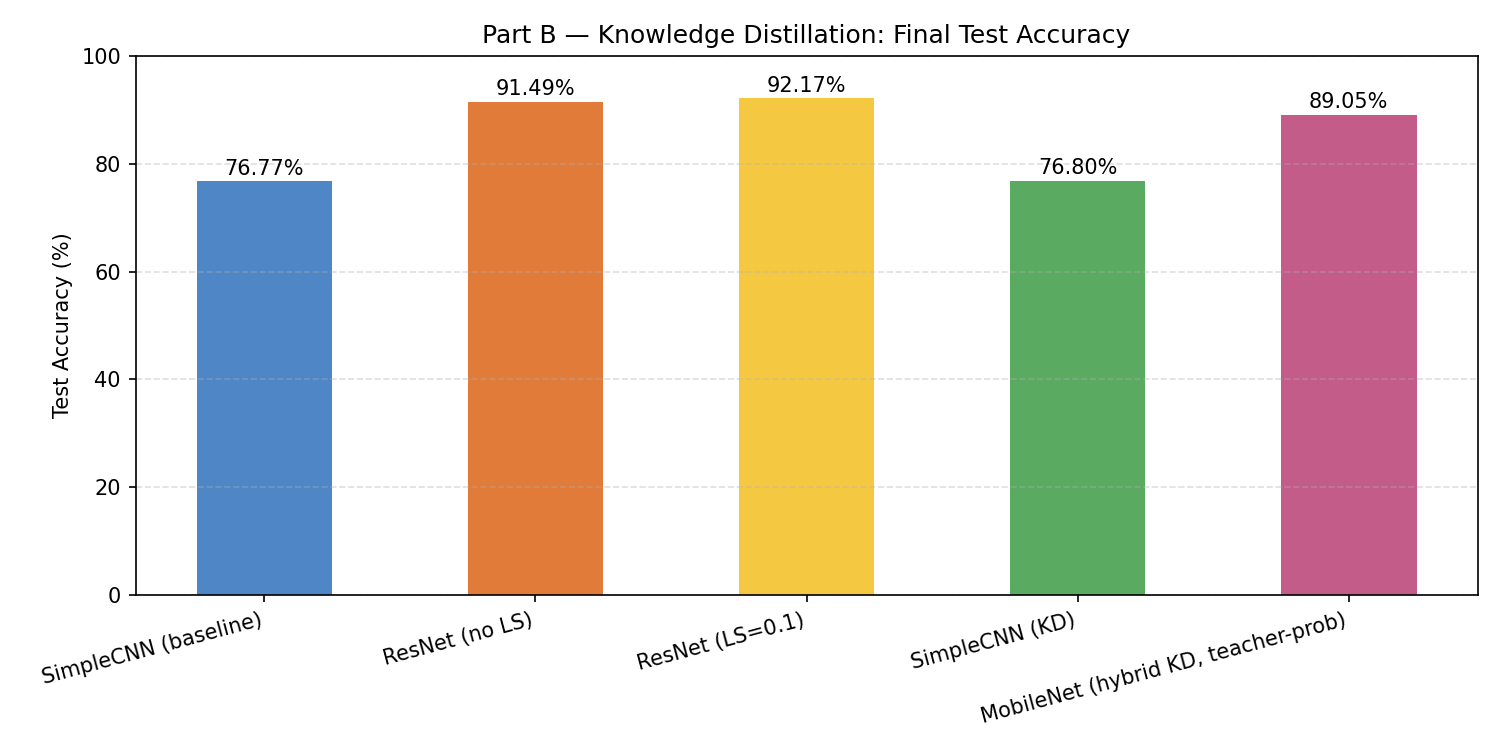

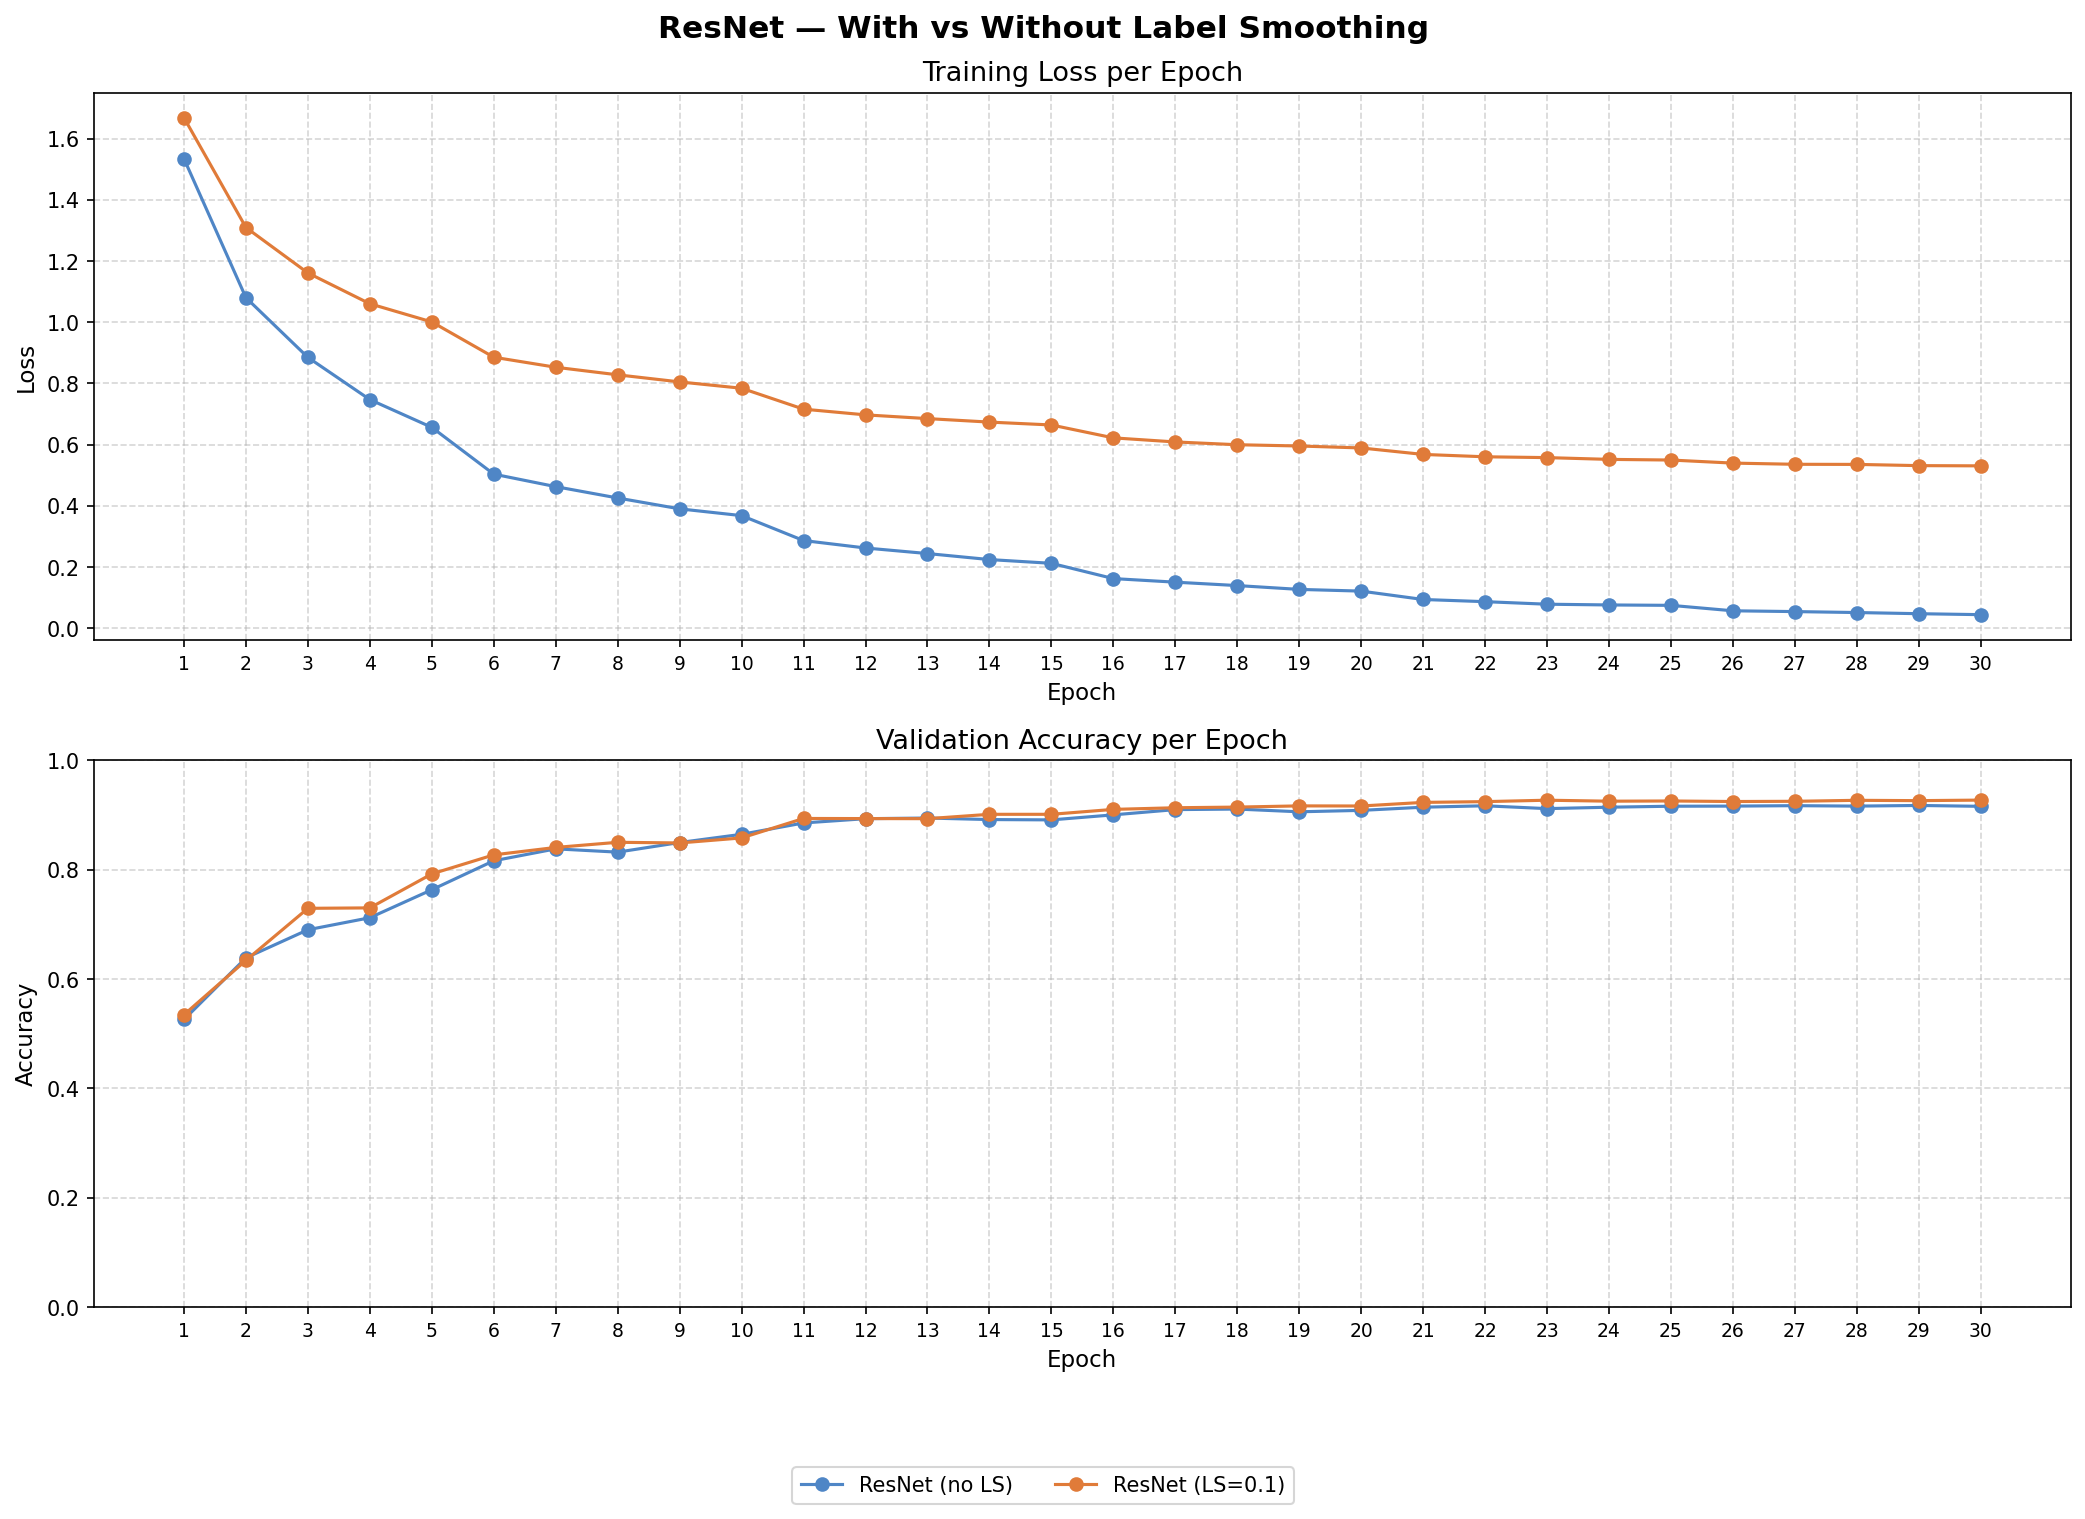

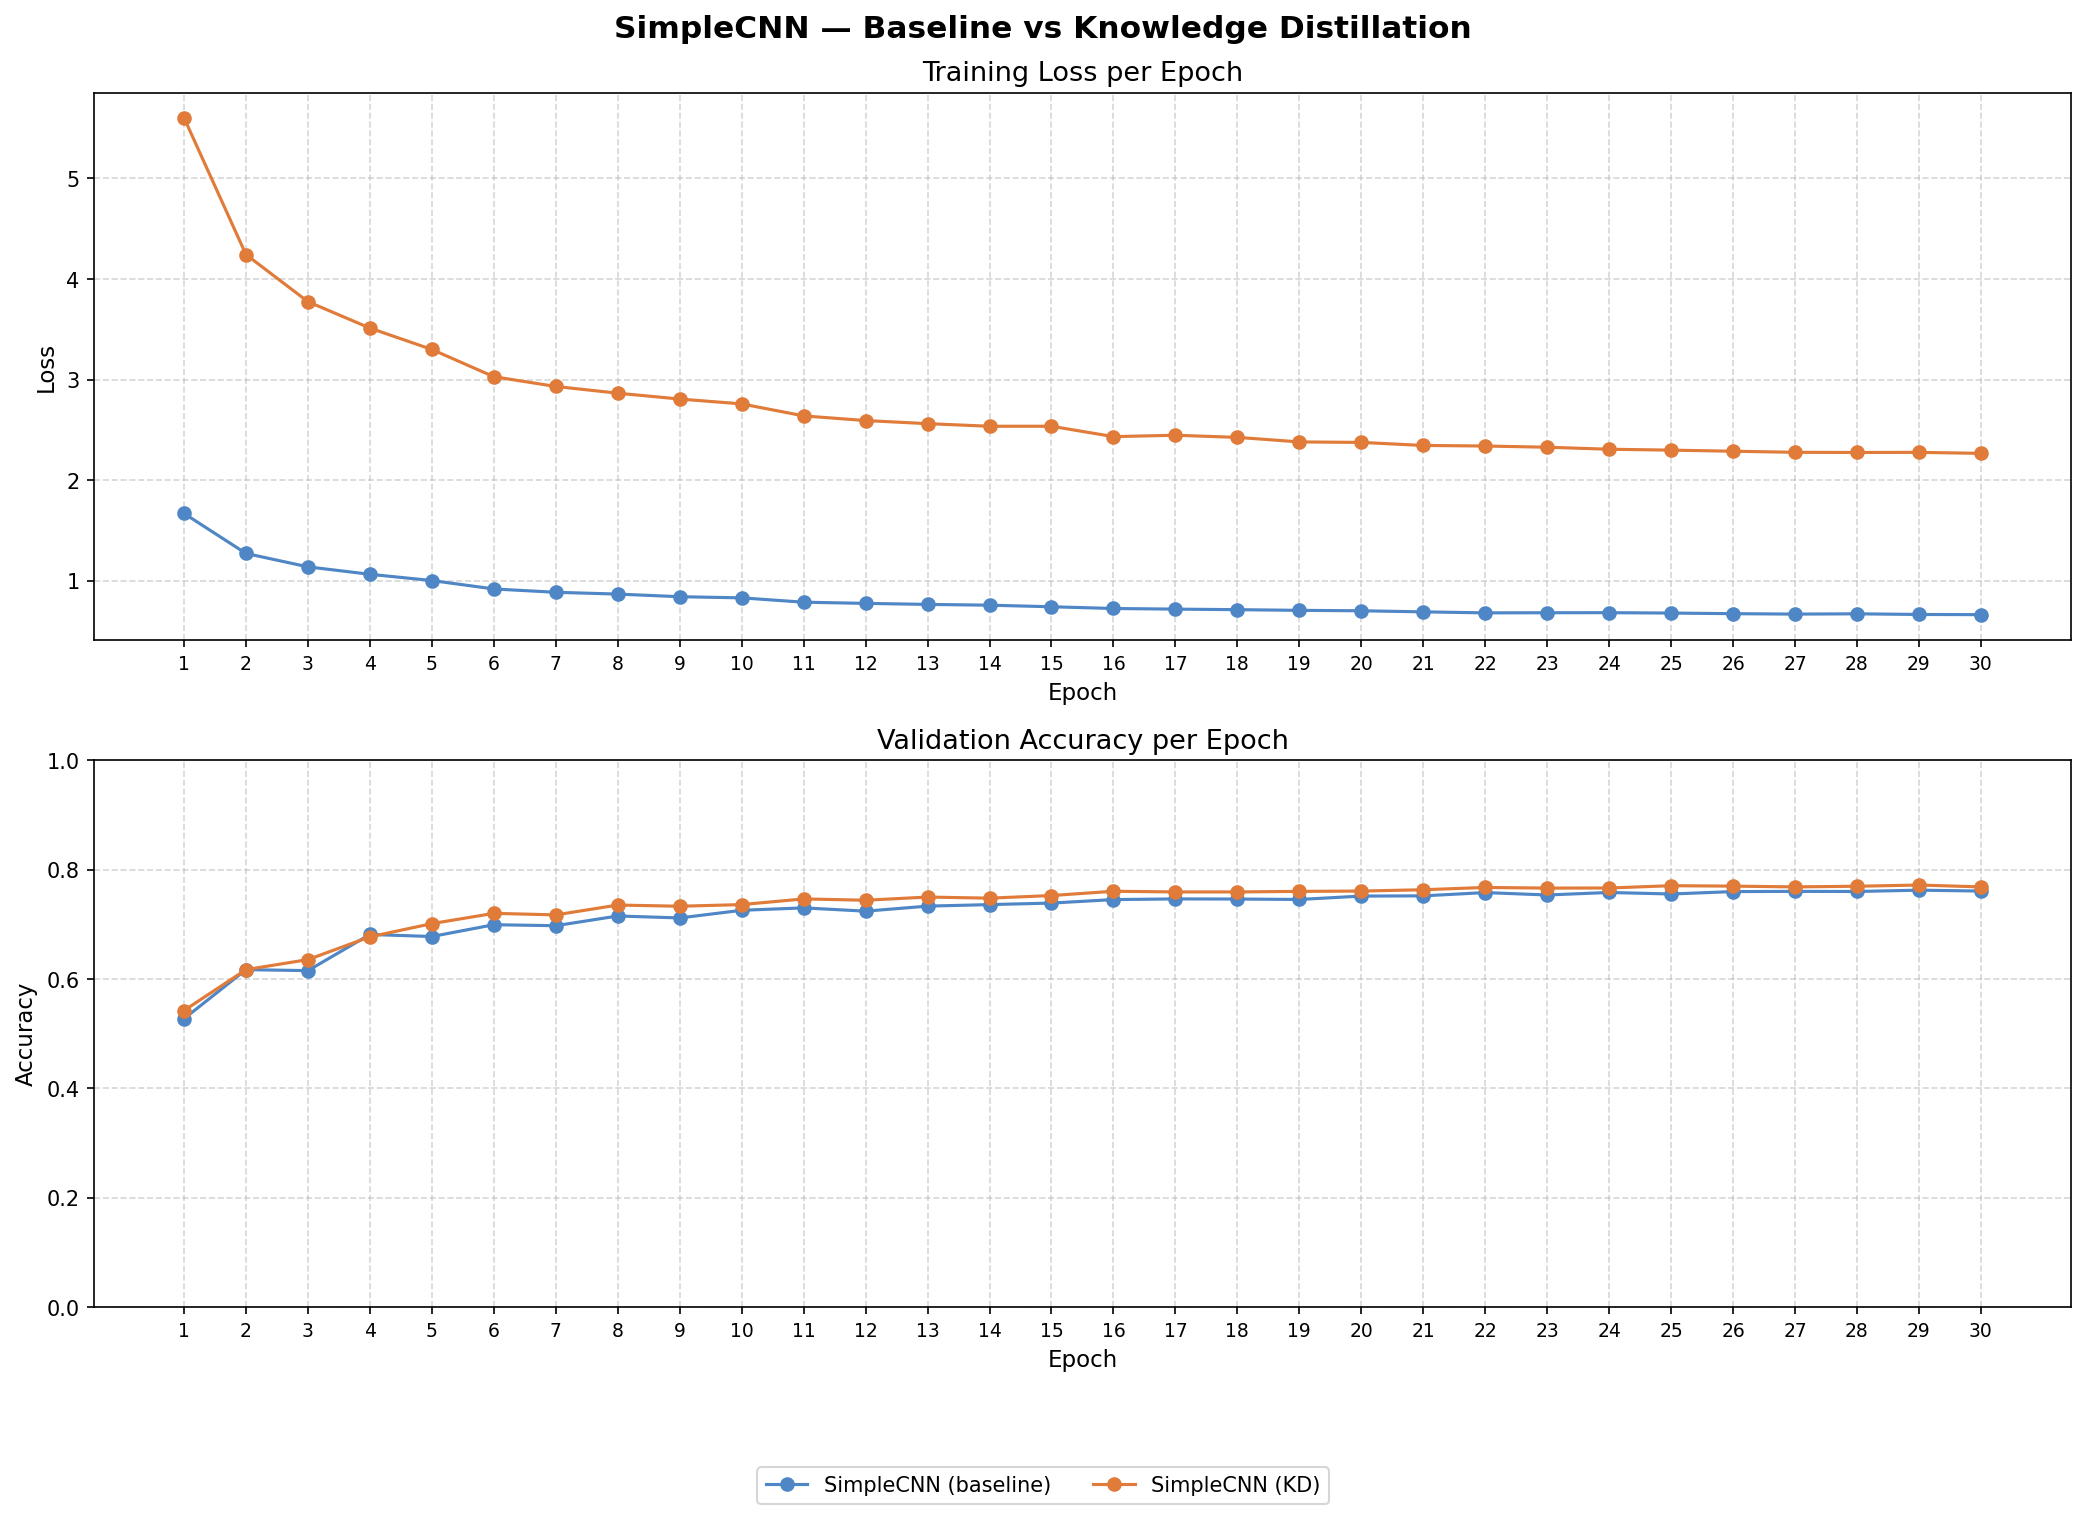

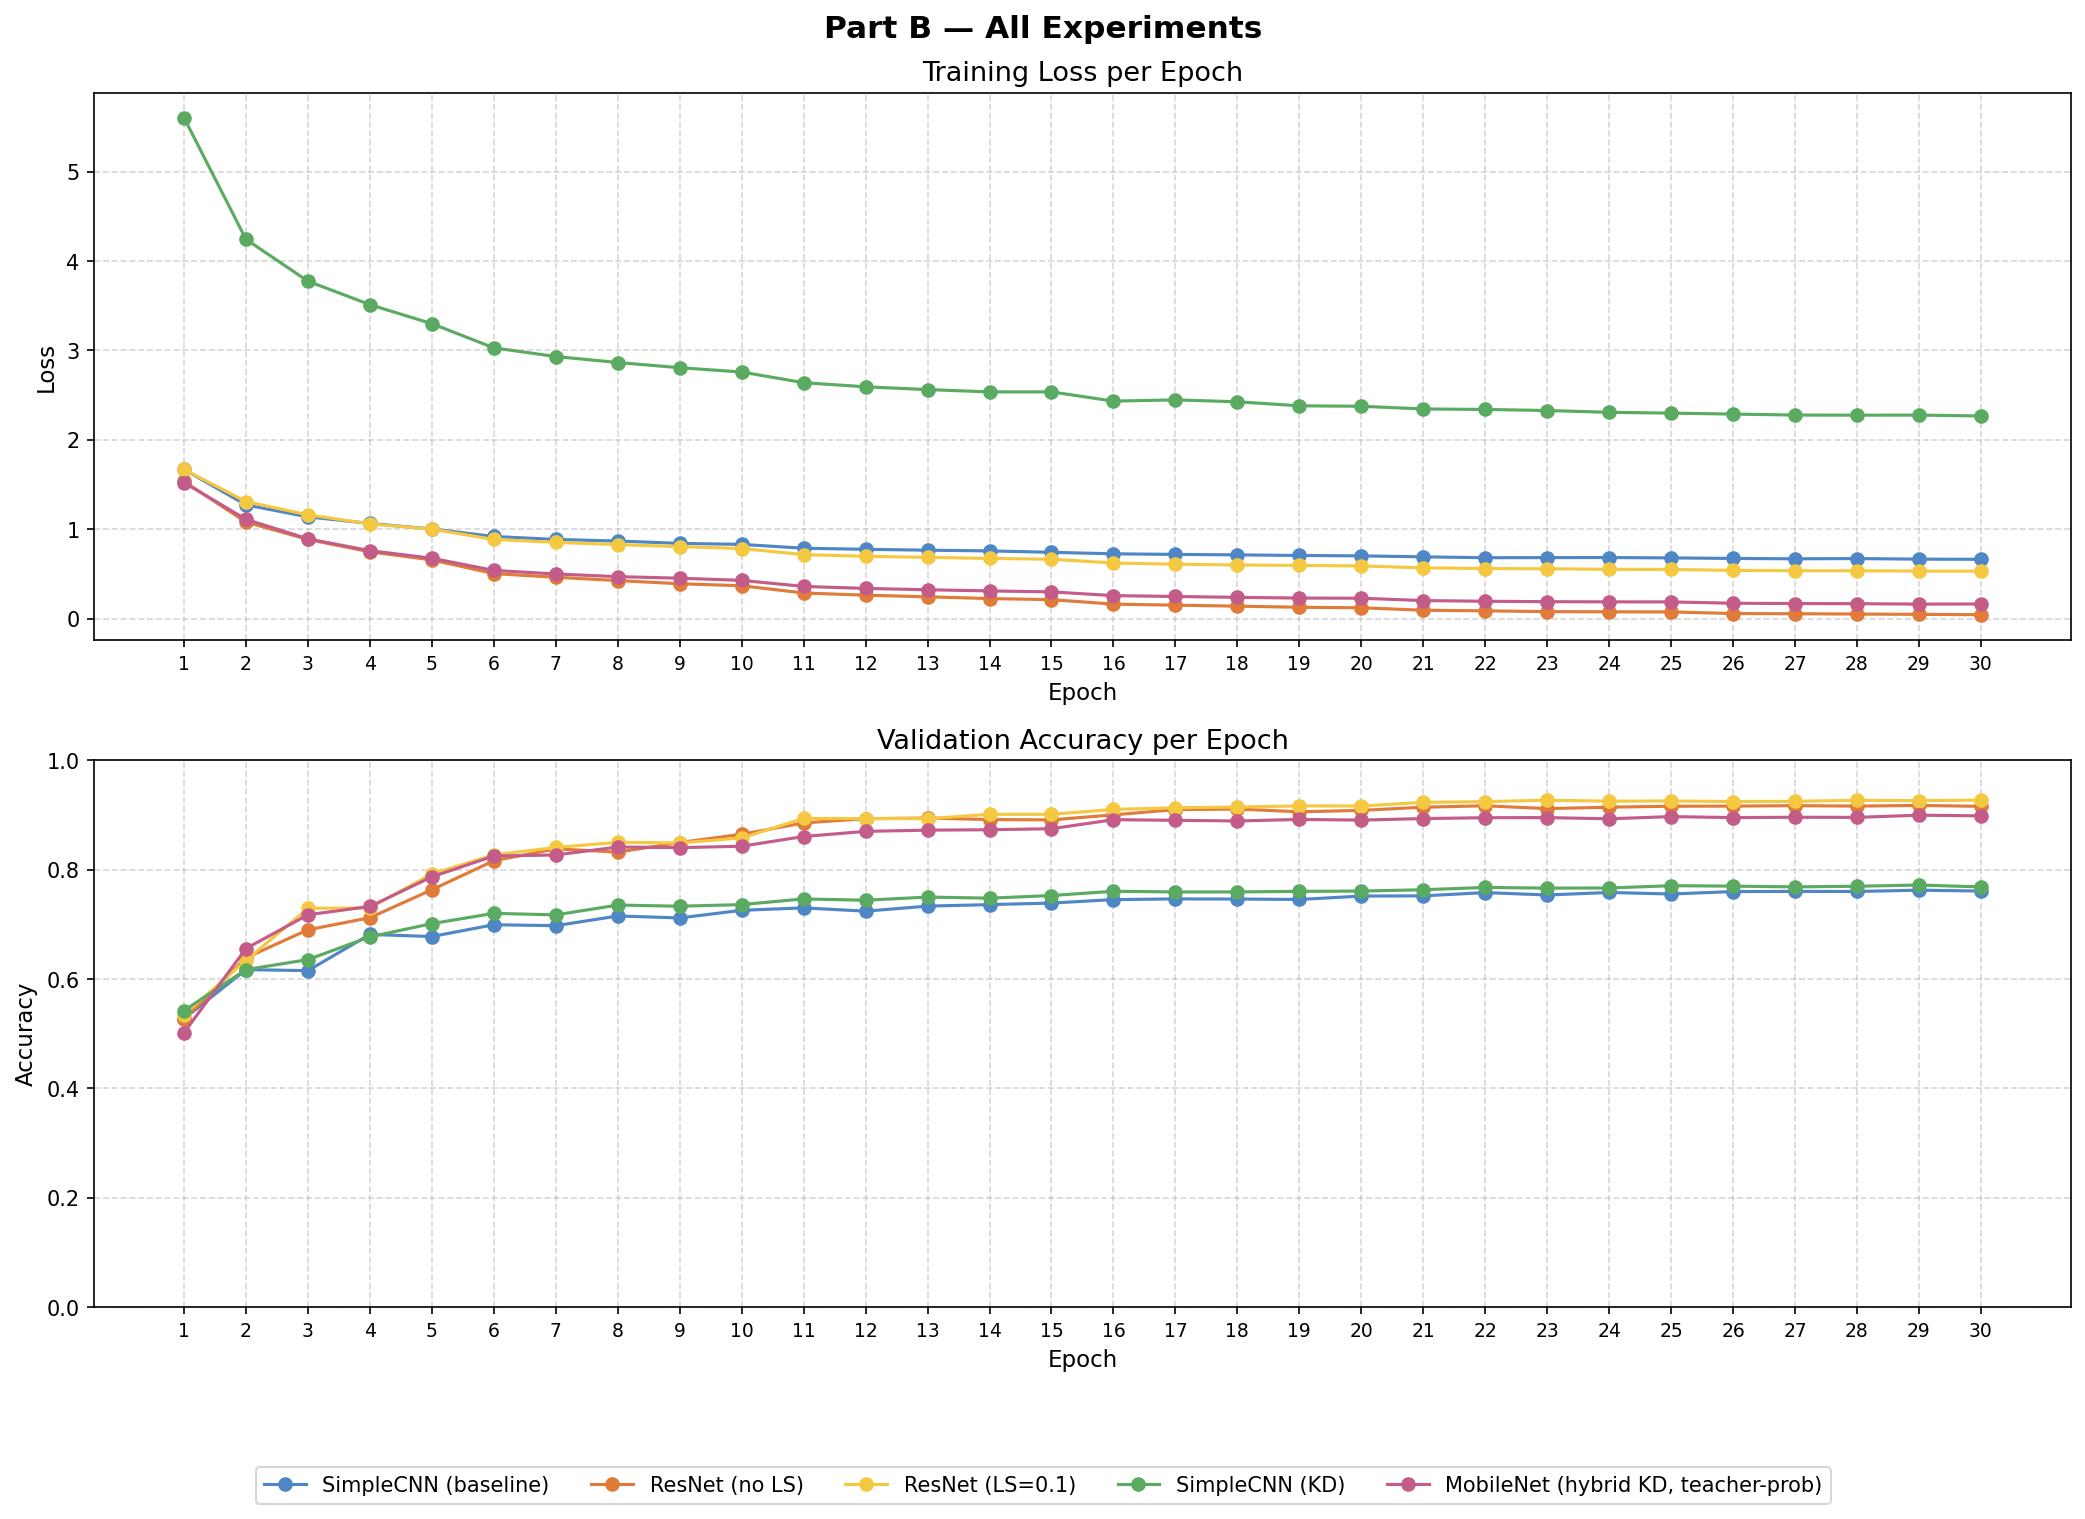

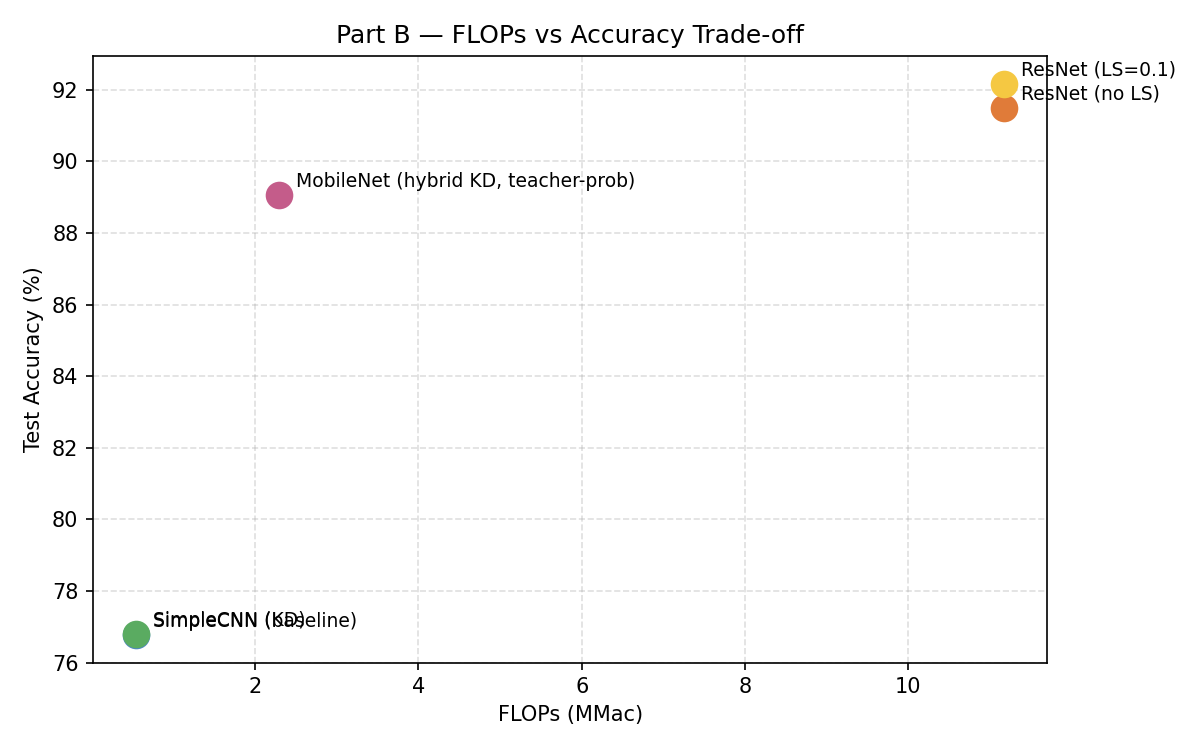

In [22]:
from IPython.display import Image, display

display(Image('/content/deep-learning-cifar10-transfer-learning-and-distillation/b_final_comparison.png'))
display(Image('/content/deep-learning-cifar10-transfer-learning-and-distillation/b2_label_smoothing.png'))
display(Image('/content/deep-learning-cifar10-transfer-learning-and-distillation/b3_kd_effect.png'))
display(Image('/content/deep-learning-cifar10-transfer-learning-and-distillation/b_all_curves.png'))
display(Image('/content/deep-learning-cifar10-transfer-learning-and-distillation/b_flops_accuracy.png'))

In [23]:
from google.colab import files

files.download('/content/deep-learning-cifar10-transfer-learning-and-distillation/b_final_comparison.png')
files.download('/content/deep-learning-cifar10-transfer-learning-and-distillation/b2_label_smoothing.png')
files.download('/content/deep-learning-cifar10-transfer-learning-and-distillation/b3_kd_effect.png')
files.download('/content/deep-learning-cifar10-transfer-learning-and-distillation/b_all_curves.png')
files.download('/content/deep-learning-cifar10-transfer-learning-and-distillation/b_flops_accuracy.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!python generate_torchviz.py

Generating ResNet-18 graph...
Saved: torchviz_resnet18.png
Generating SimpleCNN graph...
Saved: torchviz_simplecnn.png
Generating MobileNetV2 graph...
Saved: torchviz_mobilenet.png

All graphs saved. Add them to your report as Figures 1, 2, 3.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cp *.png /content/drive/MyDrive/Deep-learning-hw1b/

In [ ]:
!cp *.pth /content/drive/MyDrive/Deep-learning-hw1b/

In [ ]:
!cp *.json /content/drive/MyDrive/Deep-learning-hw1b/

In [ ]:
from PIL import Image

images = [
    "torchviz_resnet18.png",
    "torchviz_simplecnn.png"
]

for fname in images:
    img = Image.open(fname).convert("RGB")
    pdf_name = fname.replace(".png", ".pdf")
    img.save(pdf_name, "PDF", resolution=150)
    print(f"Saved: {pdf_name}")

Saved: torchviz_resnet18.pdf
Saved: torchviz_simplecnn.pdf


In [ ]:
!cp torchviz_*.pdf /content/drive/MyDrive/Deep-learning-hw1b/

cp: target '/content/drive/MyDrive/Deep-learning-hw1b/' is not a directory
